In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

In [8]:
img = cv2.imread('./images/checker.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [9]:
# harris -> array yg menanmpung angka-angka hasil deteksi corner
harris = cv2.cornerHarris(gray, 2, 5, 0.01)

harrisImg = img.copy()
harrisImg[harris > 0.01 * harris.max()] = [0, 0, 255]
harrisImg = cv2.cvtColor(harrisImg, cv2.COLOR_BGR2RGB)

In [10]:
# subpixel
_, threshold = cv2.threshold(harris, 0.01 * harris.max(), 255, cv2.THRESH_BINARY)
threshold = np.uint8(threshold)
_, _, _, cens = cv2.connectedComponentsWithStats(threshold)
cens = np.float32(cens)

corners = cv2.cornerSubPix(
    gray,
    cens,
    (5, 5),
    (-1, -1),
    (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 40, 0.001),
)

subpix = img.copy()
h, w = subpix.shape[:2]
for corner in corners:
    x, y = np.rint(corner).astype(int)
    if 0 <= x < w and 0 <= y < h:
        subpix[y, x] = [0, 0, 255]
subpix = cv2.cvtColor(subpix, cv2.COLOR_BGR2RGB)

In [ ]:
# feature detector
IMAGES_PATH = './images/'

fast = cv2.FastFeatureDetector_create()
orb = cv2.ORB_create()

for filename in os.listdir(IMAGES_PATH):
    filepath = os.path.join(IMAGES_PATH, filename)

    # Skip if it's a directory
    if not os.path.isfile(filepath):
        continue

    # Skip if not an image file
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tiff')):
        continue

    img = cv2.imread(filepath)

    # Skip if image failed to load
    if img is None:
        continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    keypoints_fast = fast.detect(gray, None)
    keypoints_orb = orb.detect(gray, None)

    img_fast = cv2.drawKeypoints(
        img, keypoints_fast, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
    )
    img_orb = cv2.drawKeypoints(
        img, keypoints_orb, None, color=(0, 255, 0), flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
	)

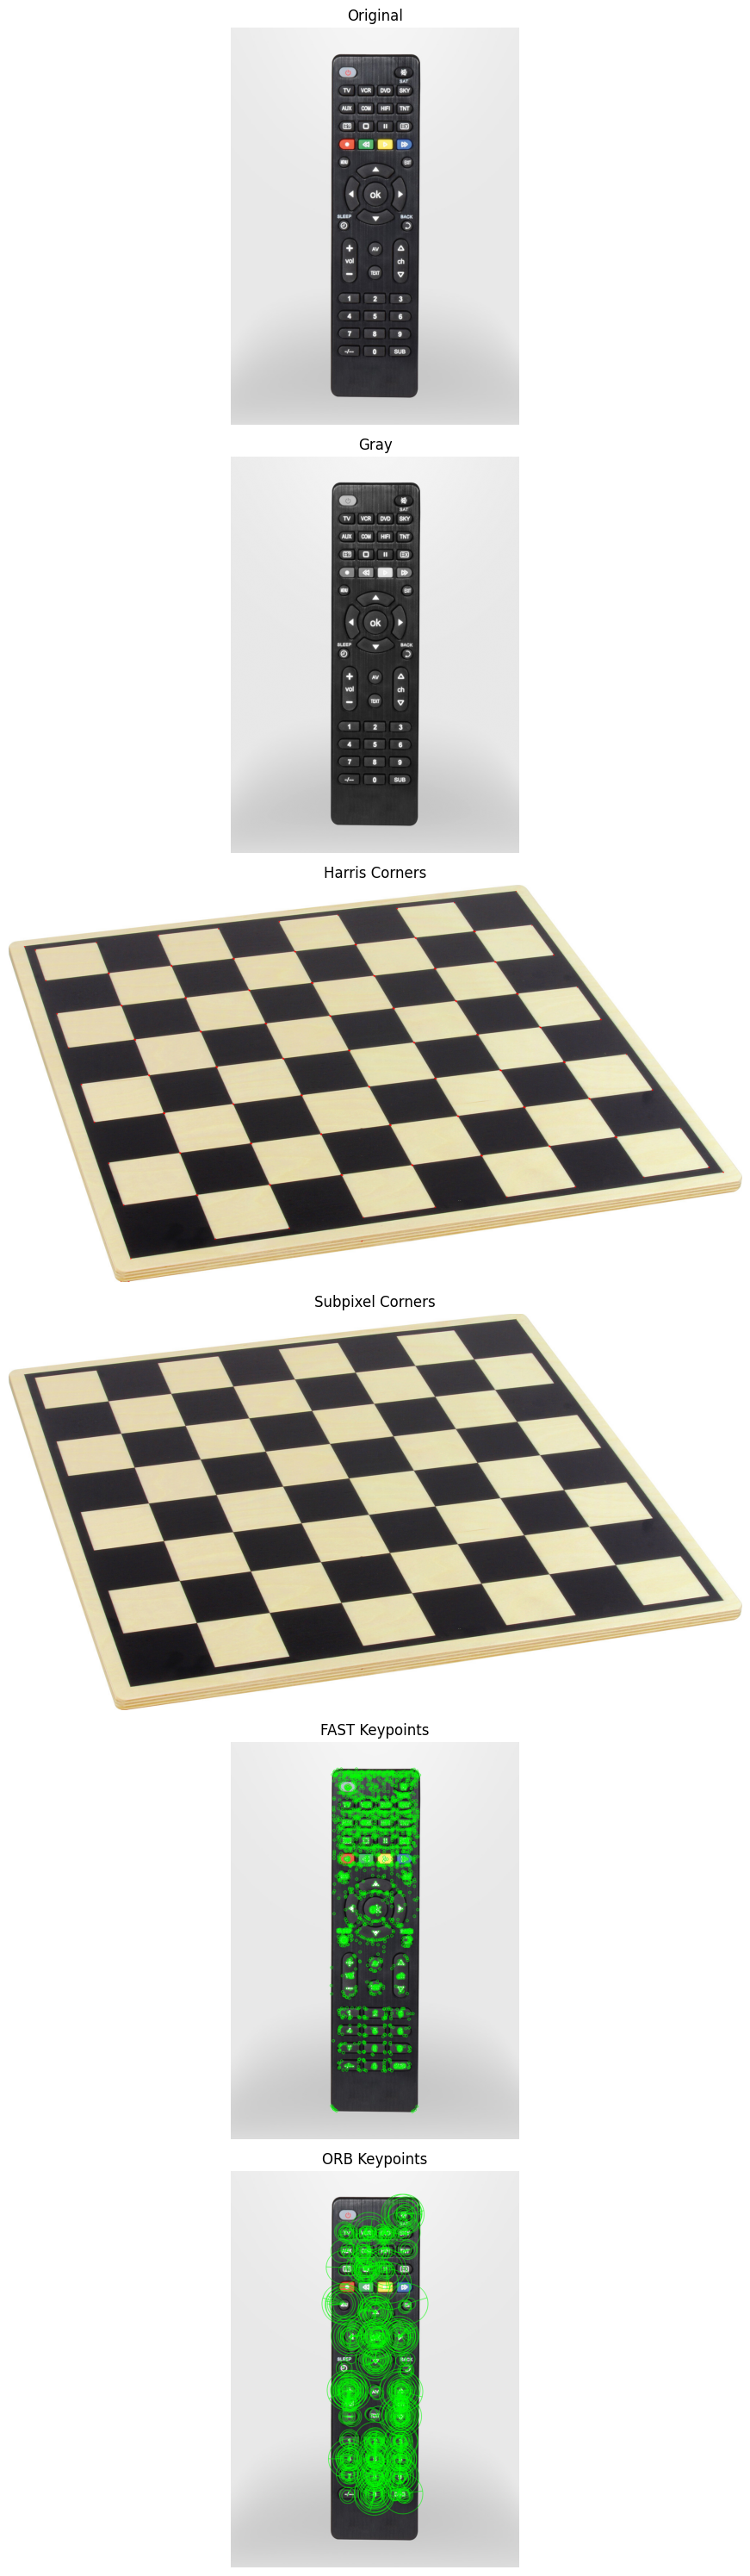

In [14]:
images = {
    'Original': cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
    'Gray': gray,
    'Harris Corners': harrisImg,
    'Subpixel Corners': subpix,
    'FAST Keypoints': cv2.cvtColor(img_fast, cv2.COLOR_BGR2RGB),
    'ORB Keypoints': cv2.cvtColor(img_orb, cv2.COLOR_BGR2RGB)
}

num_images = len(images)
plt.figure(figsize=(15, 5 * num_images))
for i, (title, image) in enumerate(images.items(), start=1):
    plt.subplot(num_images, 1, i)
    plt.imshow(image, cmap='gray' if len(image.shape) == 2 else None)
    plt.title(title)
    plt.axis('off')

plt.tight_layout()
plt.show()